In [1]:
import sys
import pandas as pd
from pathlib import Path
from torch.utils.data import DataLoader

BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(BASE_DIR))

from src import (
    # train_and_apply_cascade,  # при обучении
    CascadeImputer,  # при применении
    
    GeophysicalFeatureExtractor,
    DataCleansing,
    BaseDataModule,
    TensorDataset
)

def main():
    BASE_DIR = Path(__file__).resolve().parent
    RAW_DATA_PATH = BASE_DIR / "data" / "raw" / "hidden_test.csv"
    PROCESSED_DATA_PATH = BASE_DIR / "data" / "processed" / "test_preprocessed.parquet"
    MODELS_DIR = BASE_DIR / "models" / "imputers"
    
    print(f"Базовая директория: {BASE_DIR}")
    

    print("\n[1/4] Загрузка данных...")
    if not RAW_DATA_PATH.exists():
        raise FileNotFoundError(f"Файл не найден: {RAW_DATA_PATH}")

    raw_df = pd.read_csv(RAW_DATA_PATH, sep=';') 
    
    # print("\n[2/4] Запуск каскадной импутации (CatBoost)...")
    # imputed_df = train_and_apply_cascade(raw_df, models_dir=MODELS_DIR)
    
    print("\n[2/4] Применение каскадной импутации (загрузка готовых моделей)...")
    imputer = CascadeImputer(models_dir=MODELS_DIR)
    imputed_df = imputer.transform(raw_df)
    
    
    print("\n[3/4] Расчет геофизических признаков...")
    geo_extractor = GeophysicalFeatureExtractor()
    df_with_features = geo_extractor.transform(imputed_df)
    
    print("\n[4/4] Очистка и логарифмирование...")
    cleansing = DataCleansing(
        cols_to_drop = [
                    "X_LOC",
                    "Y_LOC",
                    "FORMATION",
                    "RDEP",
                    "SGR",
                    "RMED",
                    "ROP",
                    "PEF",
                    "RSHA",
                    "RXO",
                    "MUDWEIGHT",
                    "DCAL",
                    "RMIC",
                    "ROPA",
                    "WELL",
                    "FORCE_2020_LITHOFACIES_CONFIDENCE",
                    'LITHO_NAME'
                ],
        cols_to_log = ['RDEP', 'RMED', 'RSHA']
    )
    final_df = cleansing.transform(df_with_features)
    
    PROCESSED_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
    final_df.to_parquet(PROCESSED_DATA_PATH, index=False)
    print(f"\n Пайплайн завершен! Данные сохранены в: {PROCESSED_DATA_PATH}")

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, f1_score
from catboost import CatBoostClassifier, Pool
from src.pipelines import get_baseline_pipeline
from src.pipelines import get_rf_pipeline

df_test = pd.read_parquet("/Users/polina/VSCode/ML/Lithology_project/Lithology prediction/data/processed/test_preprocessed.parquet")
df_raw = pd.read_csv('/Users/polina/VSCode/ML/Lithology_project/Lithology prediction/data/raw/hidden_test.csv', sep=';')

df_test['WELL'] = df_raw['WELL'].values

y_test = df_test['FORCE_2020_LITHOFACIES_LITHOLOGY']

Модель загружена из: models/baseline_sgd.joblib
              precision    recall  f1-score   support

       30000       0.67      0.72      0.69     14045
       65000       0.88      0.84      0.86     71827
       65030       0.30      0.18      0.22     12283
       70000       0.57      0.44      0.49      8374
       70032       0.49      0.72      0.58      2905
       74000       0.05      0.21      0.08       287
       80000       0.18      0.32      0.23      4396
       86000       0.69      0.77      0.73       597
       88000       0.99      0.96      0.97      6498
       90000       0.39      0.84      0.53       244
       93000       0.00      0.00      0.00         0
       99000       0.16      0.59      0.25       941

    accuracy                           0.71    122397
   macro avg       0.45      0.55      0.47    122397
weighted avg       0.74      0.71      0.72    122397



/Users/polina/miniforge3/envs/ml_course/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/polina/miniforge3/envs/ml_course/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/polina/miniforge3/envs/ml_course/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

Матрица ошибок сохранена в: reports/figures/baseline/confusion_matrix.png


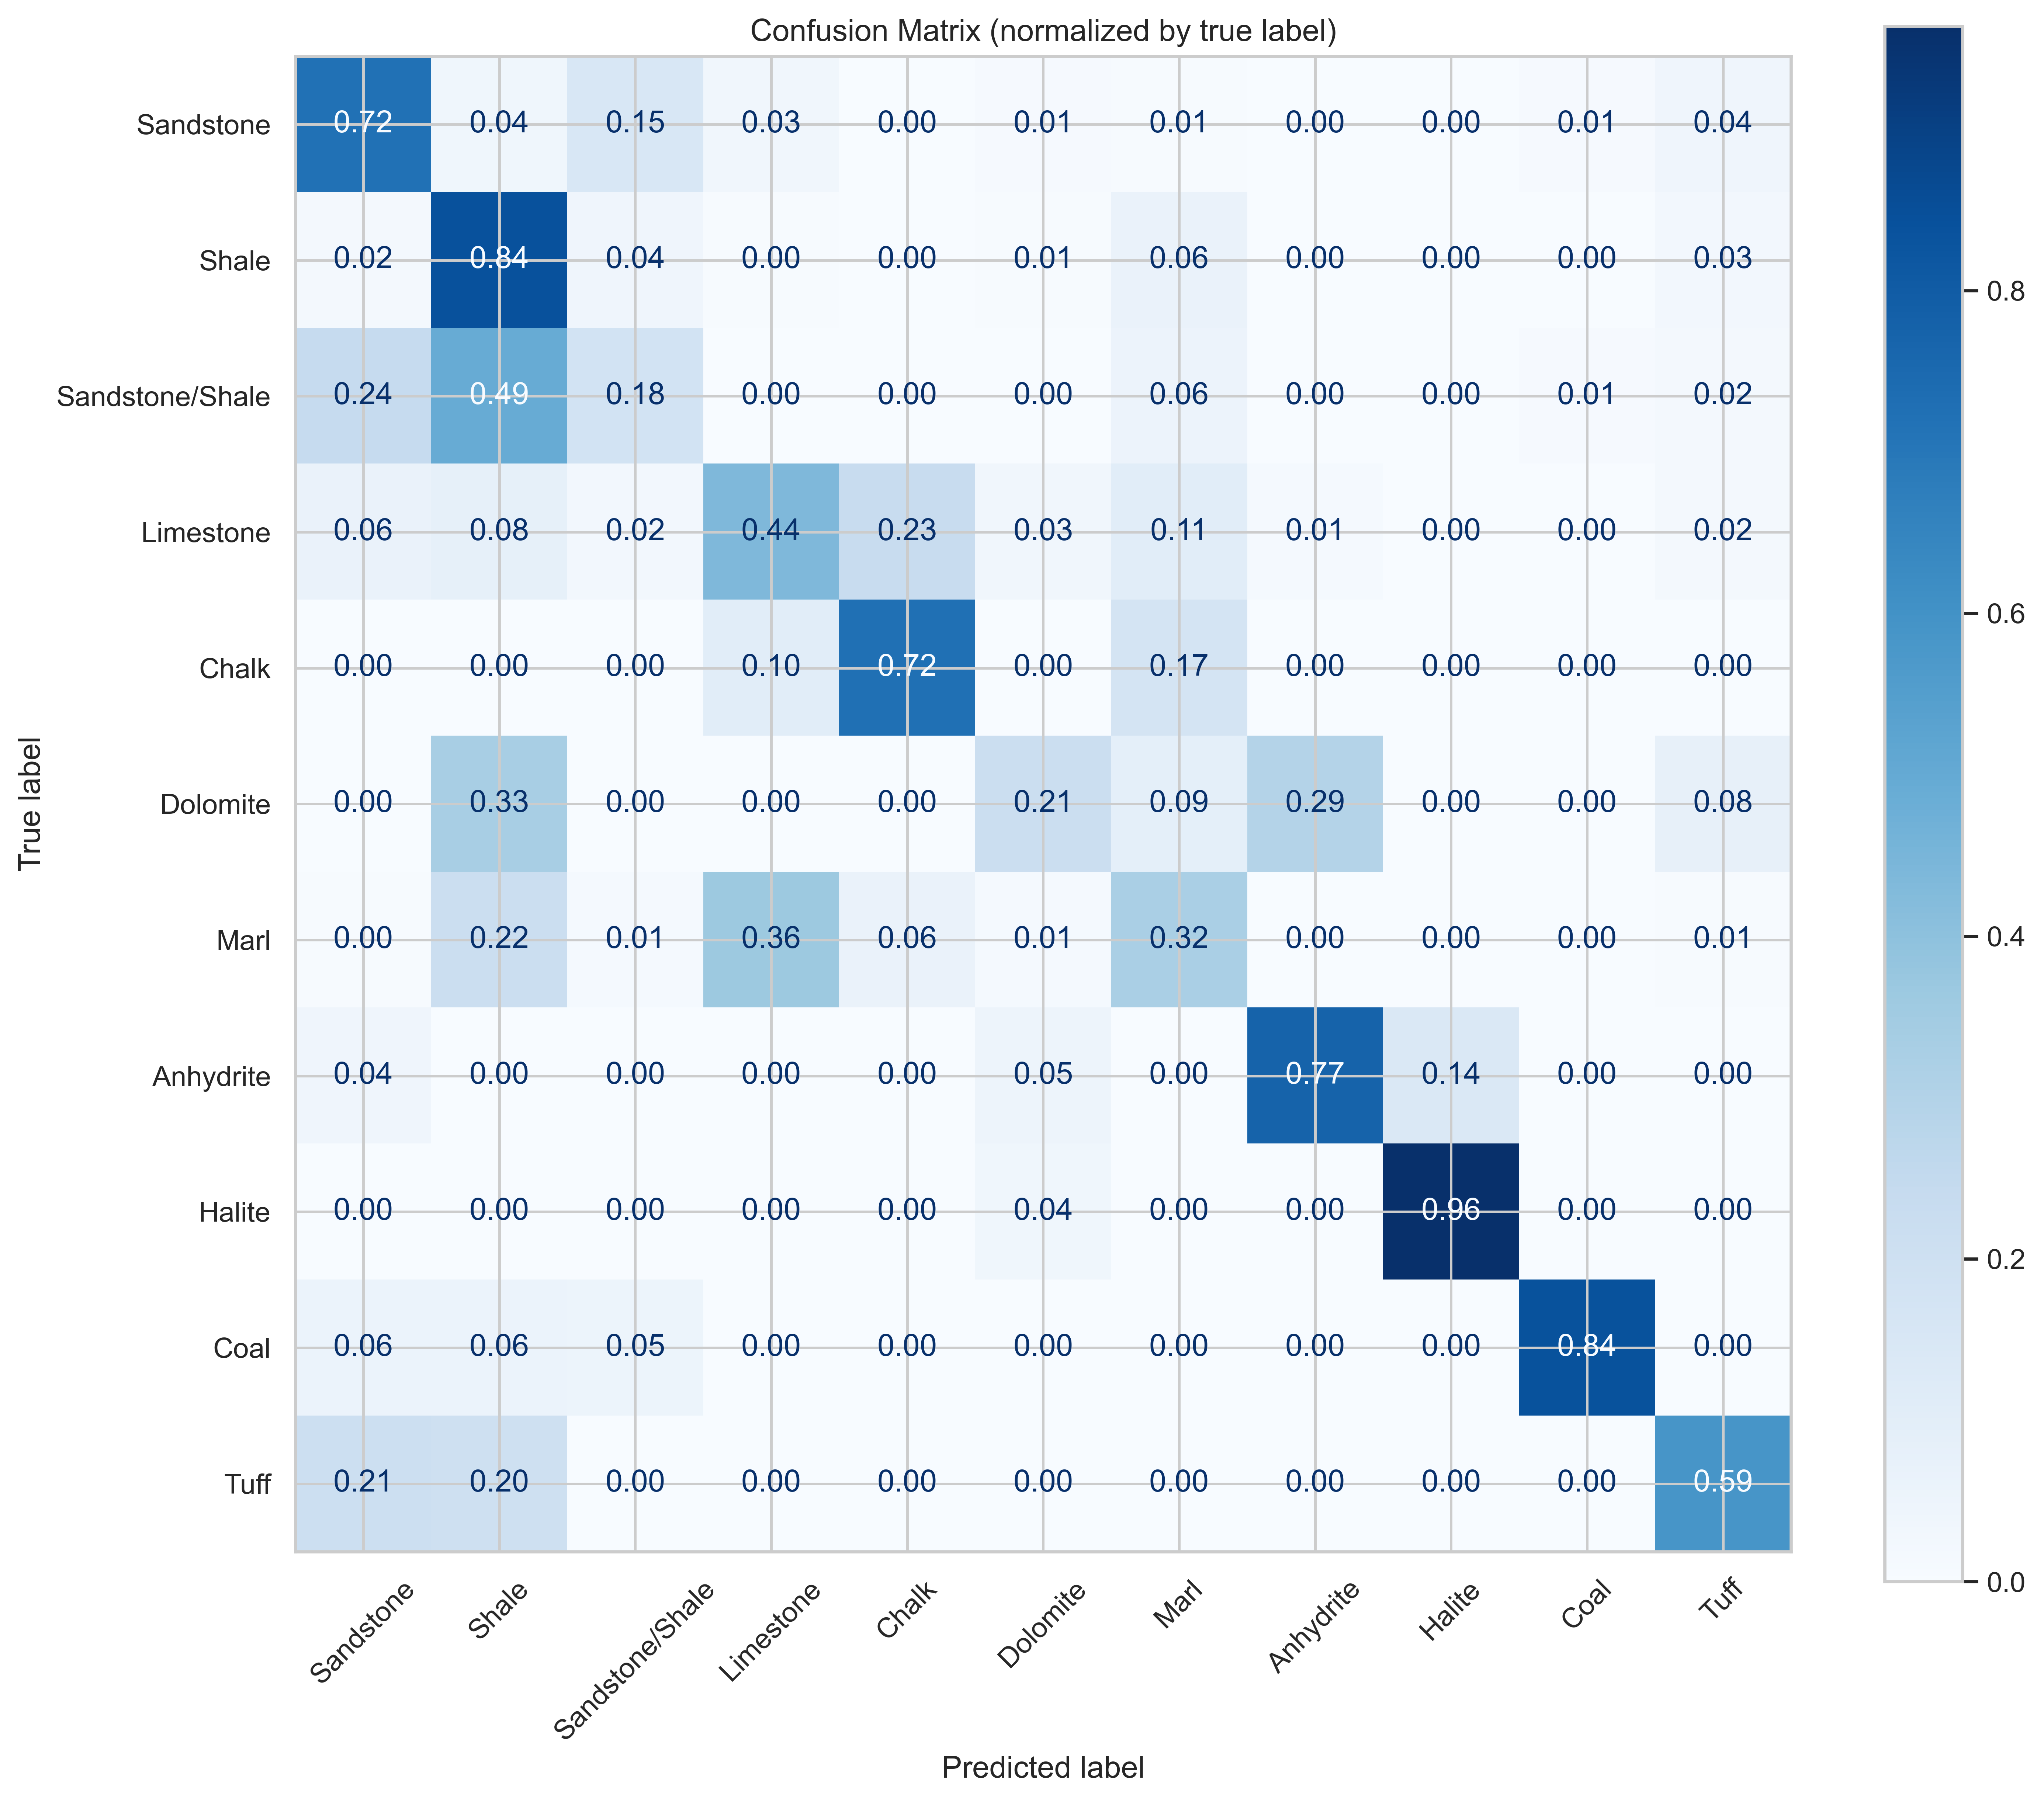

ROC-AUC графики сохранены в: reports/figures/baseline/roc_auc_curves.png


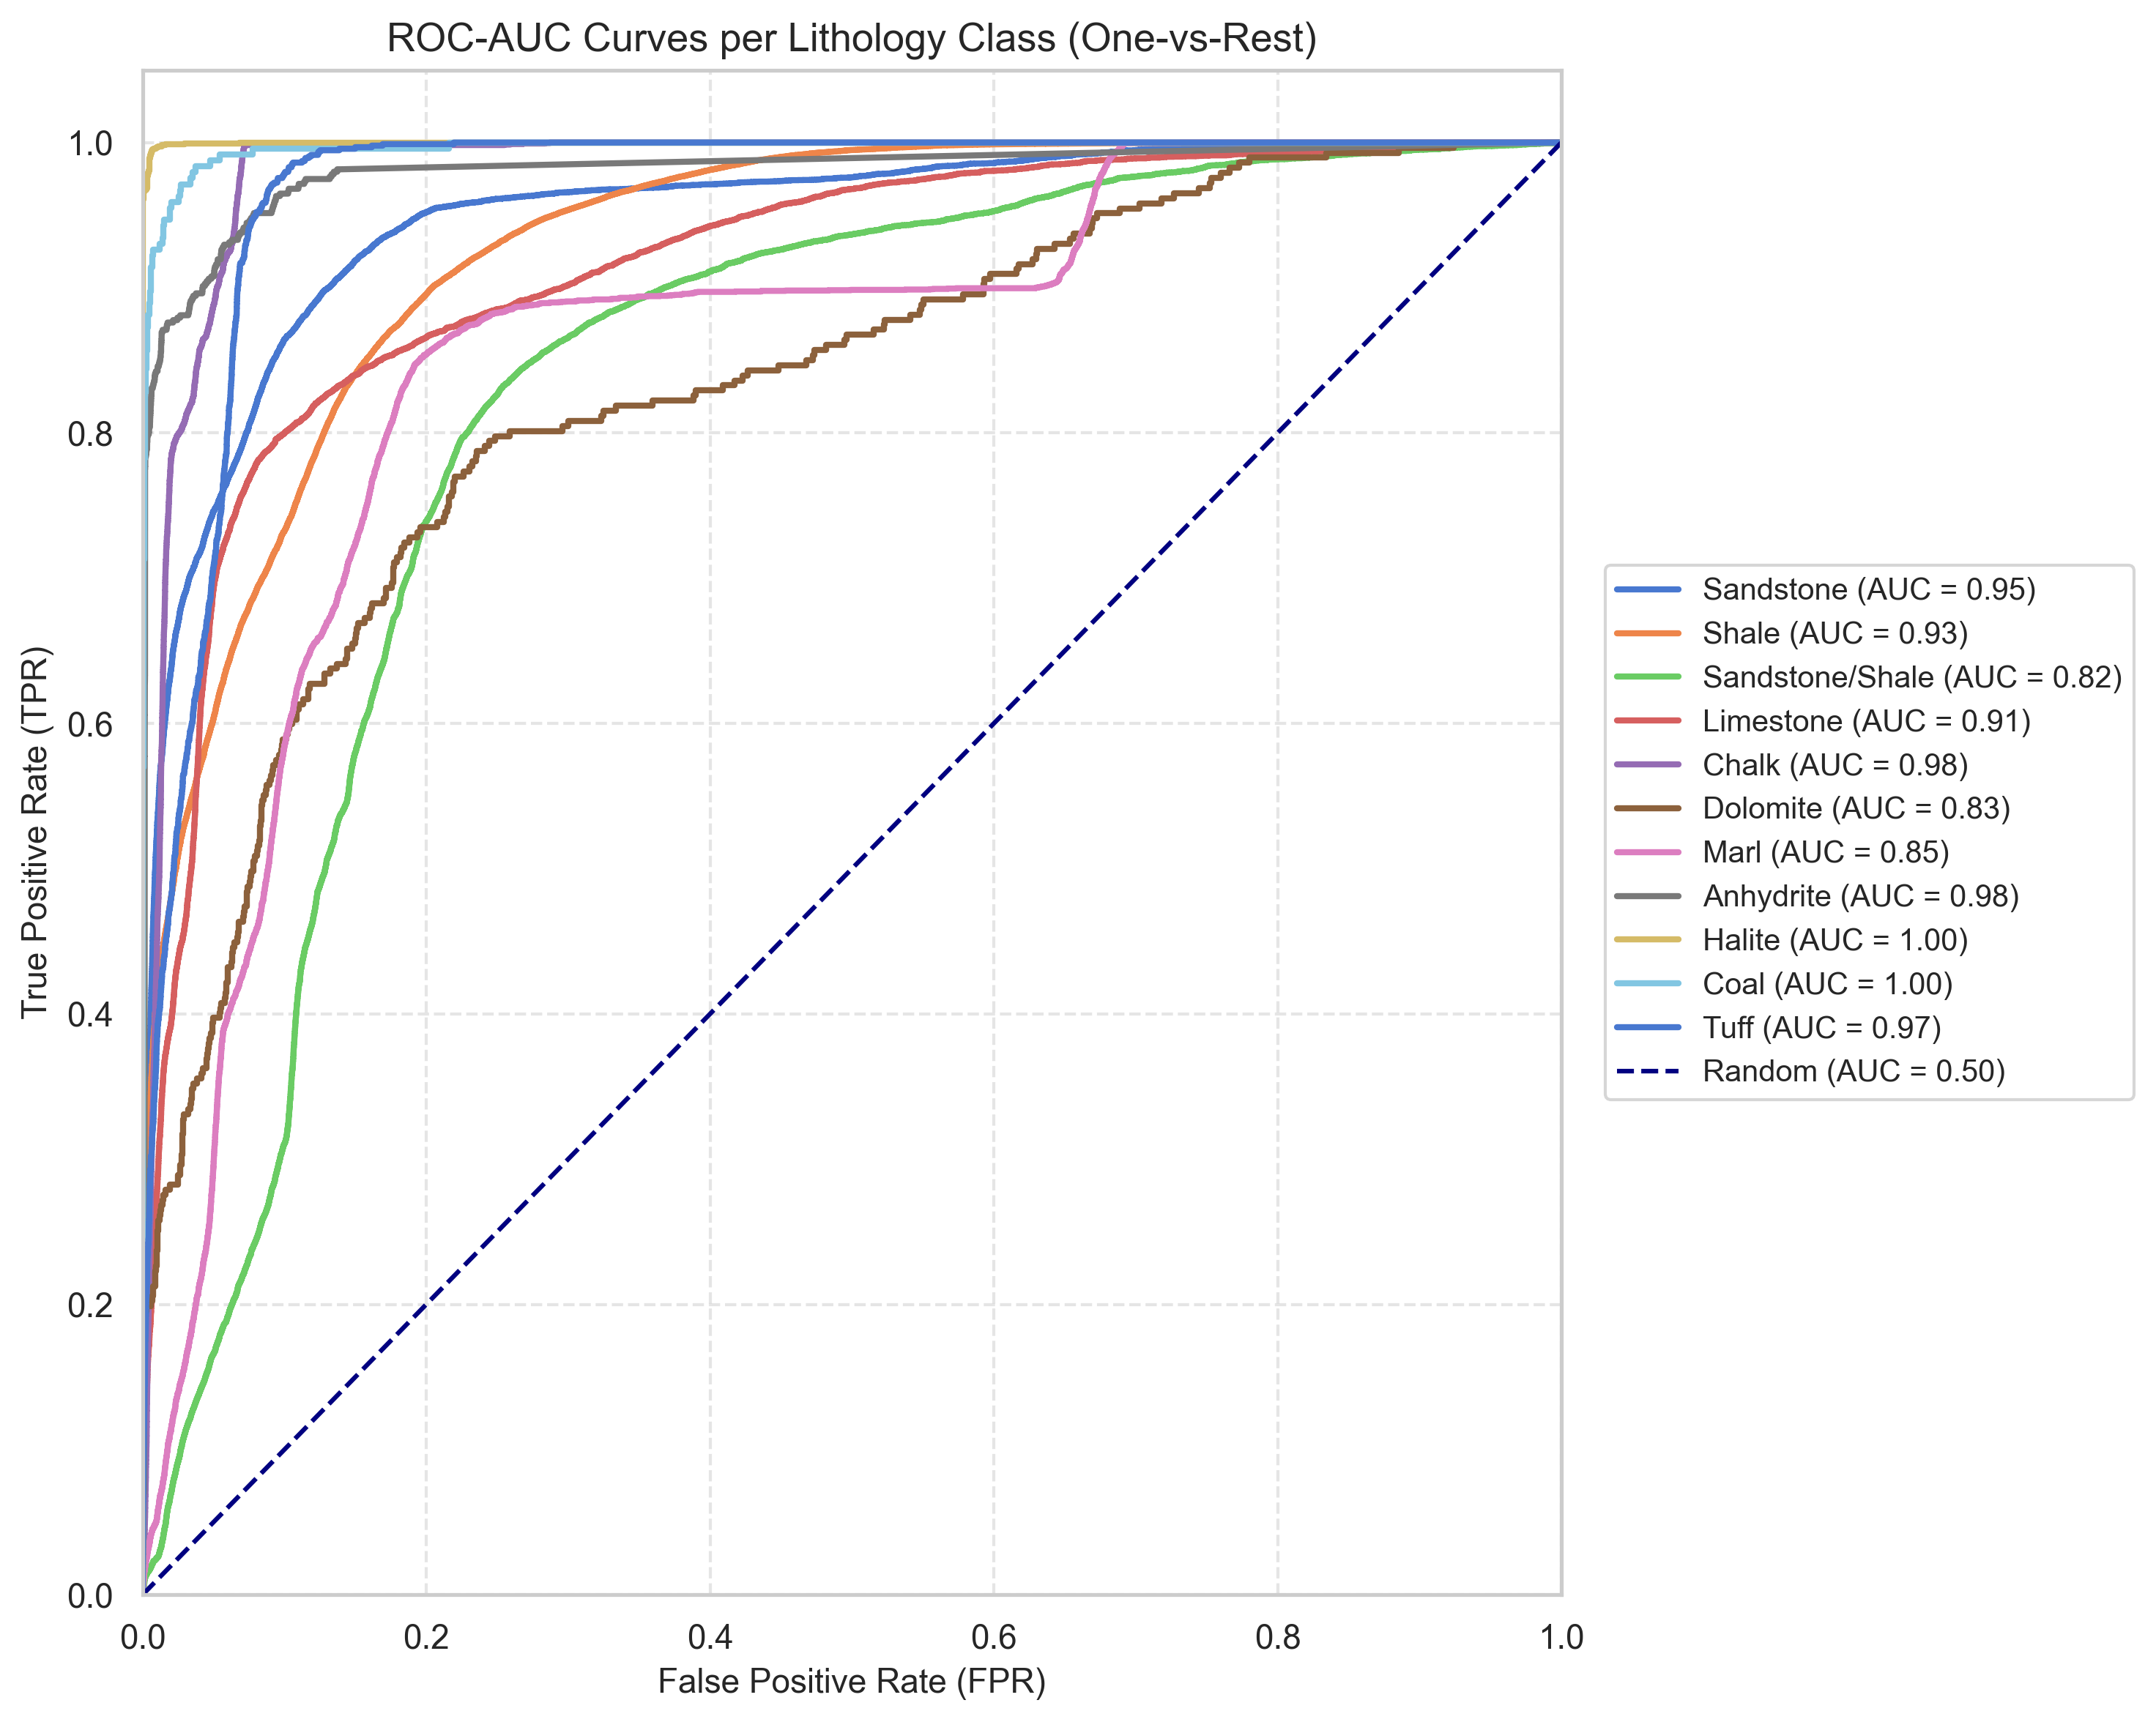

In [3]:
from src.models.baseline import Baseline
from src.metrics import LithologyEvaluator

loaded_trainer = Baseline.load('models/baseline_sgd.joblib')
preds_test = loaded_trainer.predict(df_test)
print(classification_report(y_test, preds_test))

probs_test = loaded_trainer.predict_proba(df_test)
classes = loaded_trainer.pipeline.classes_

evaluator = LithologyEvaluator()
evaluator.plot_all(
    y_true=y_test,
    y_pred=preds_test,
    val_probs=probs_test,
    classes=classes,
    output_dir="reports/figures/baseline",
)

Модель загружена из: models/random_forest_optuna.joblib
              precision    recall  f1-score   support

       30000       0.62      0.75      0.68     14045
       65000       0.82      0.95      0.88     71827
       65030       0.61      0.21      0.32     12283
       70000       0.59      0.68      0.63      8374
       70032       0.66      0.08      0.14      2905
       74000       0.00      0.00      0.00       287
       80000       0.17      0.13      0.15      4396
       86000       0.83      0.51      0.63       597
       88000       0.99      0.67      0.80      6498
       90000       0.87      0.57      0.68       244
       99000       0.65      0.17      0.27       941

    accuracy                           0.76    122397
   macro avg       0.62      0.43      0.47    122397
weighted avg       0.74      0.76      0.73    122397

Матрица ошибок сохранена в: reports/figures/rf_cb_optuna/confusion_matrix.png


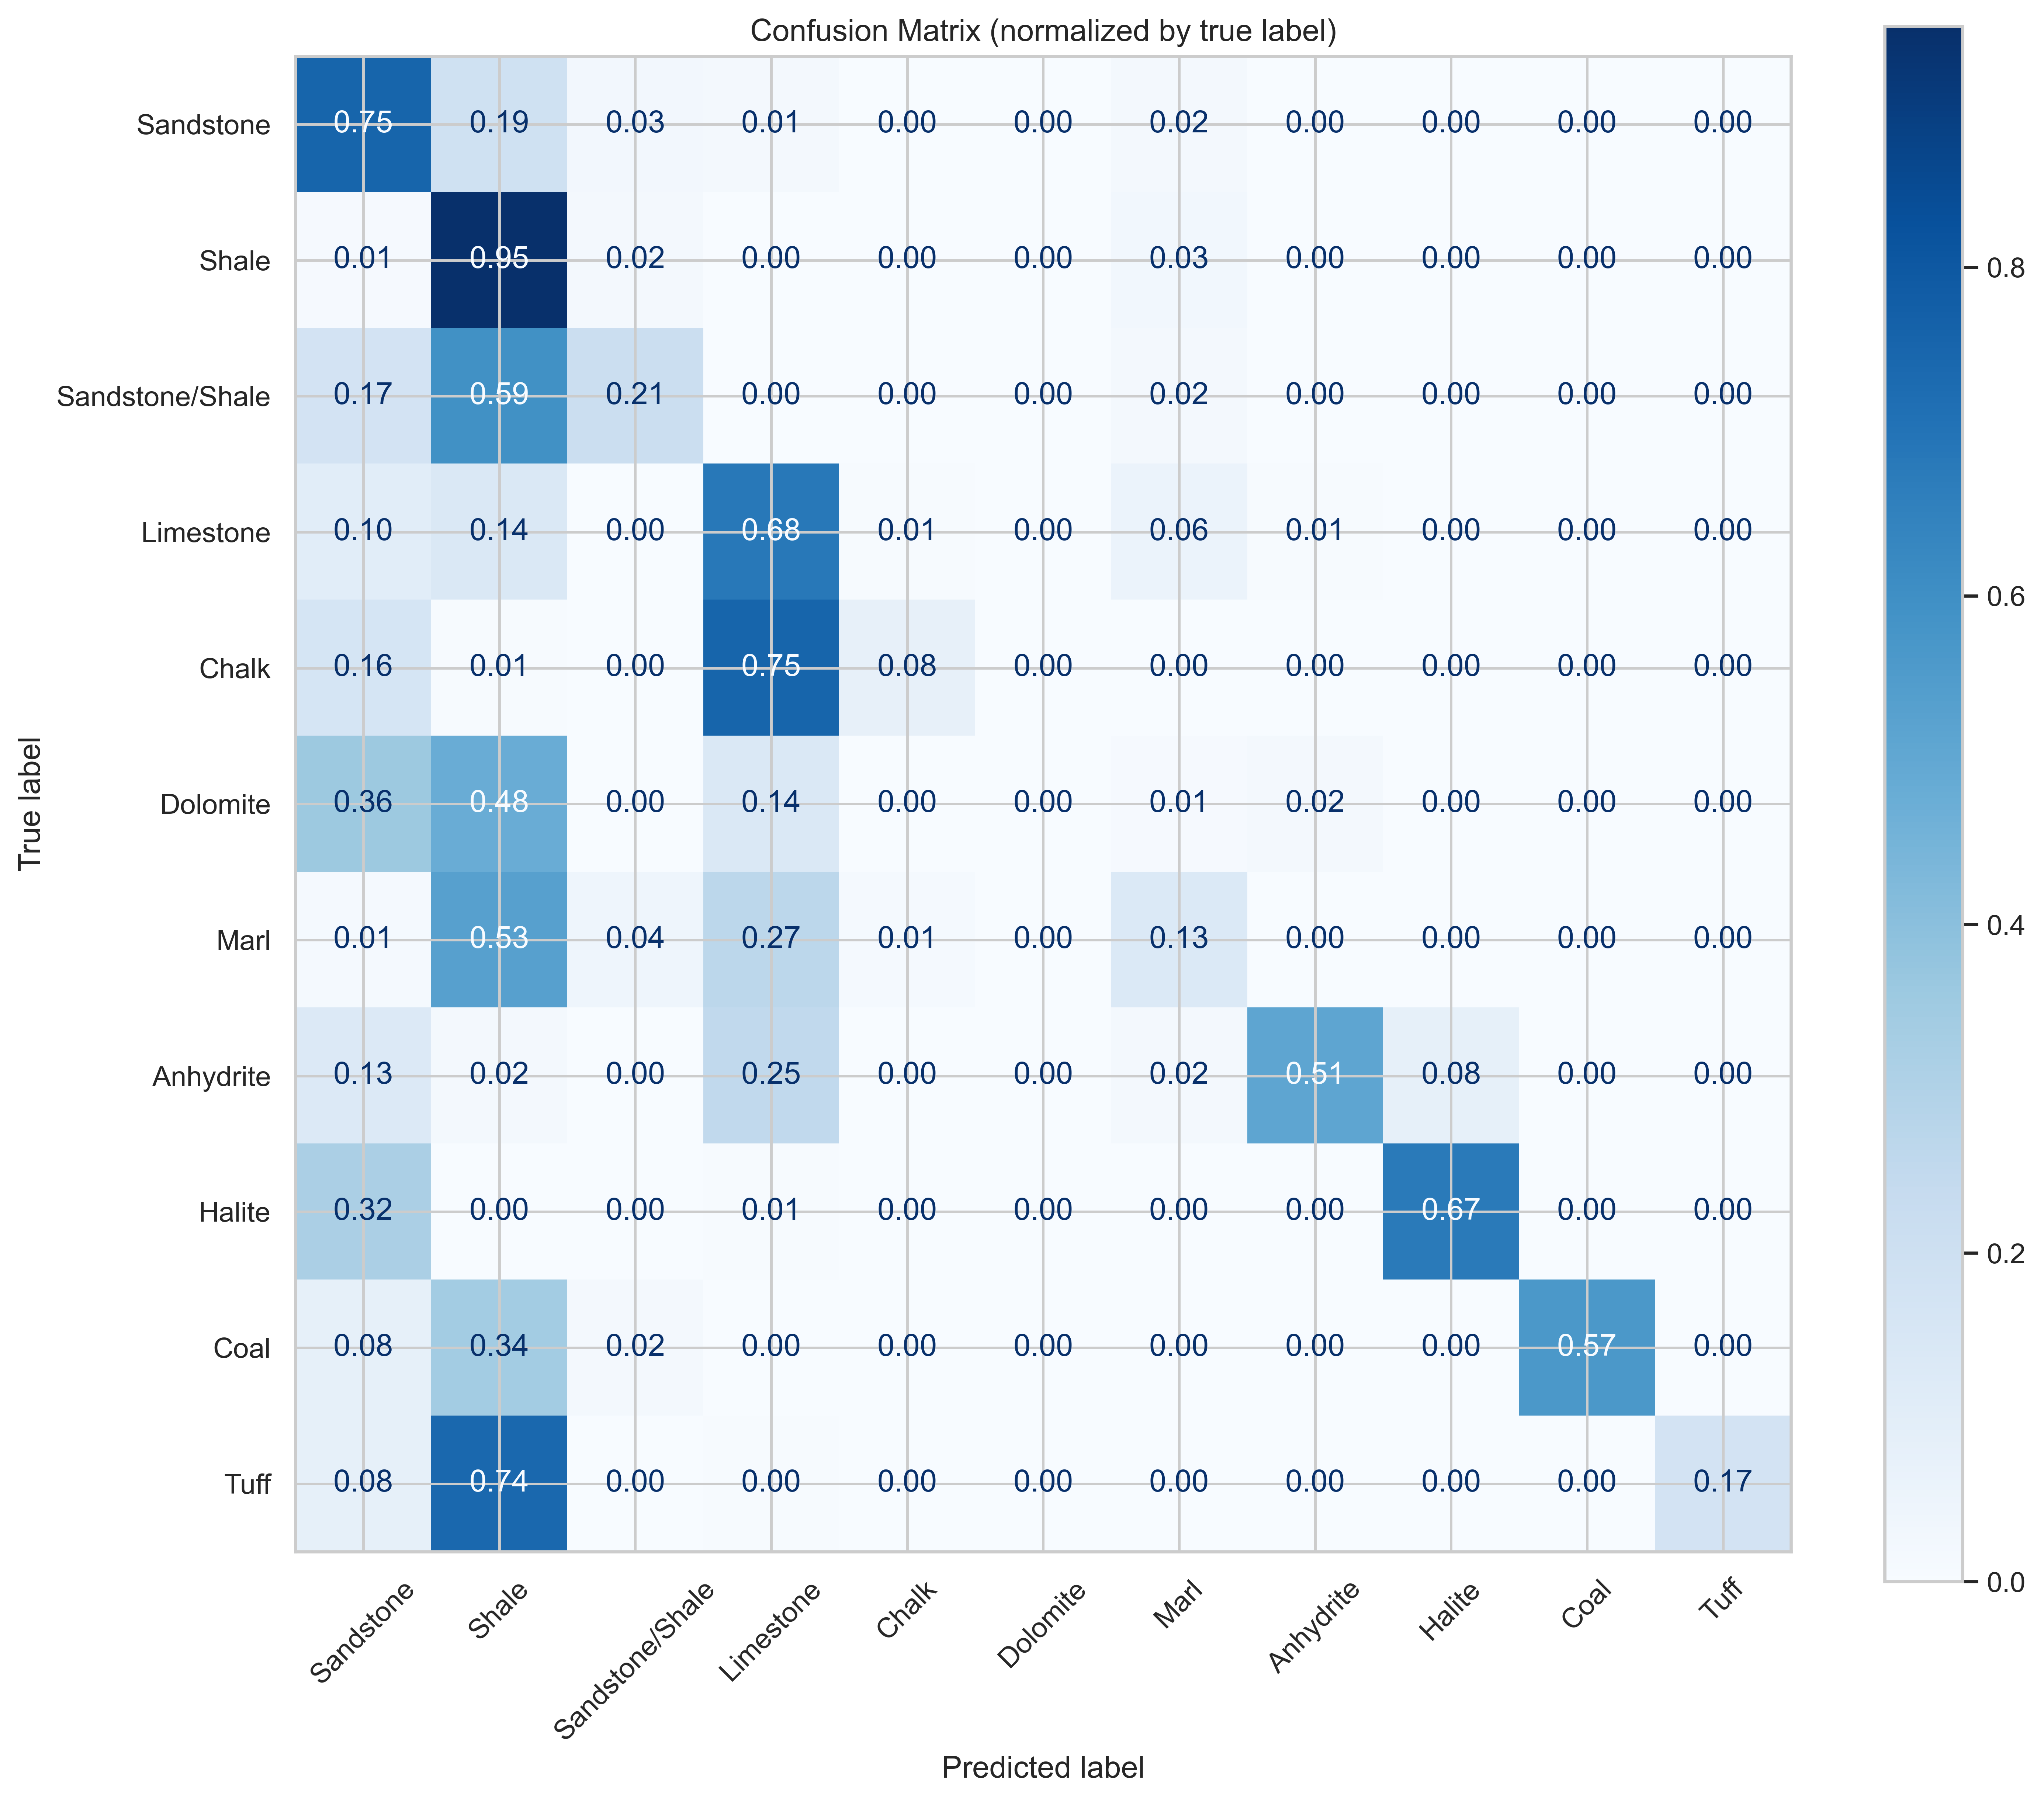

ROC-AUC графики сохранены в: reports/figures/rf_cb_optuna/roc_auc_curves.png


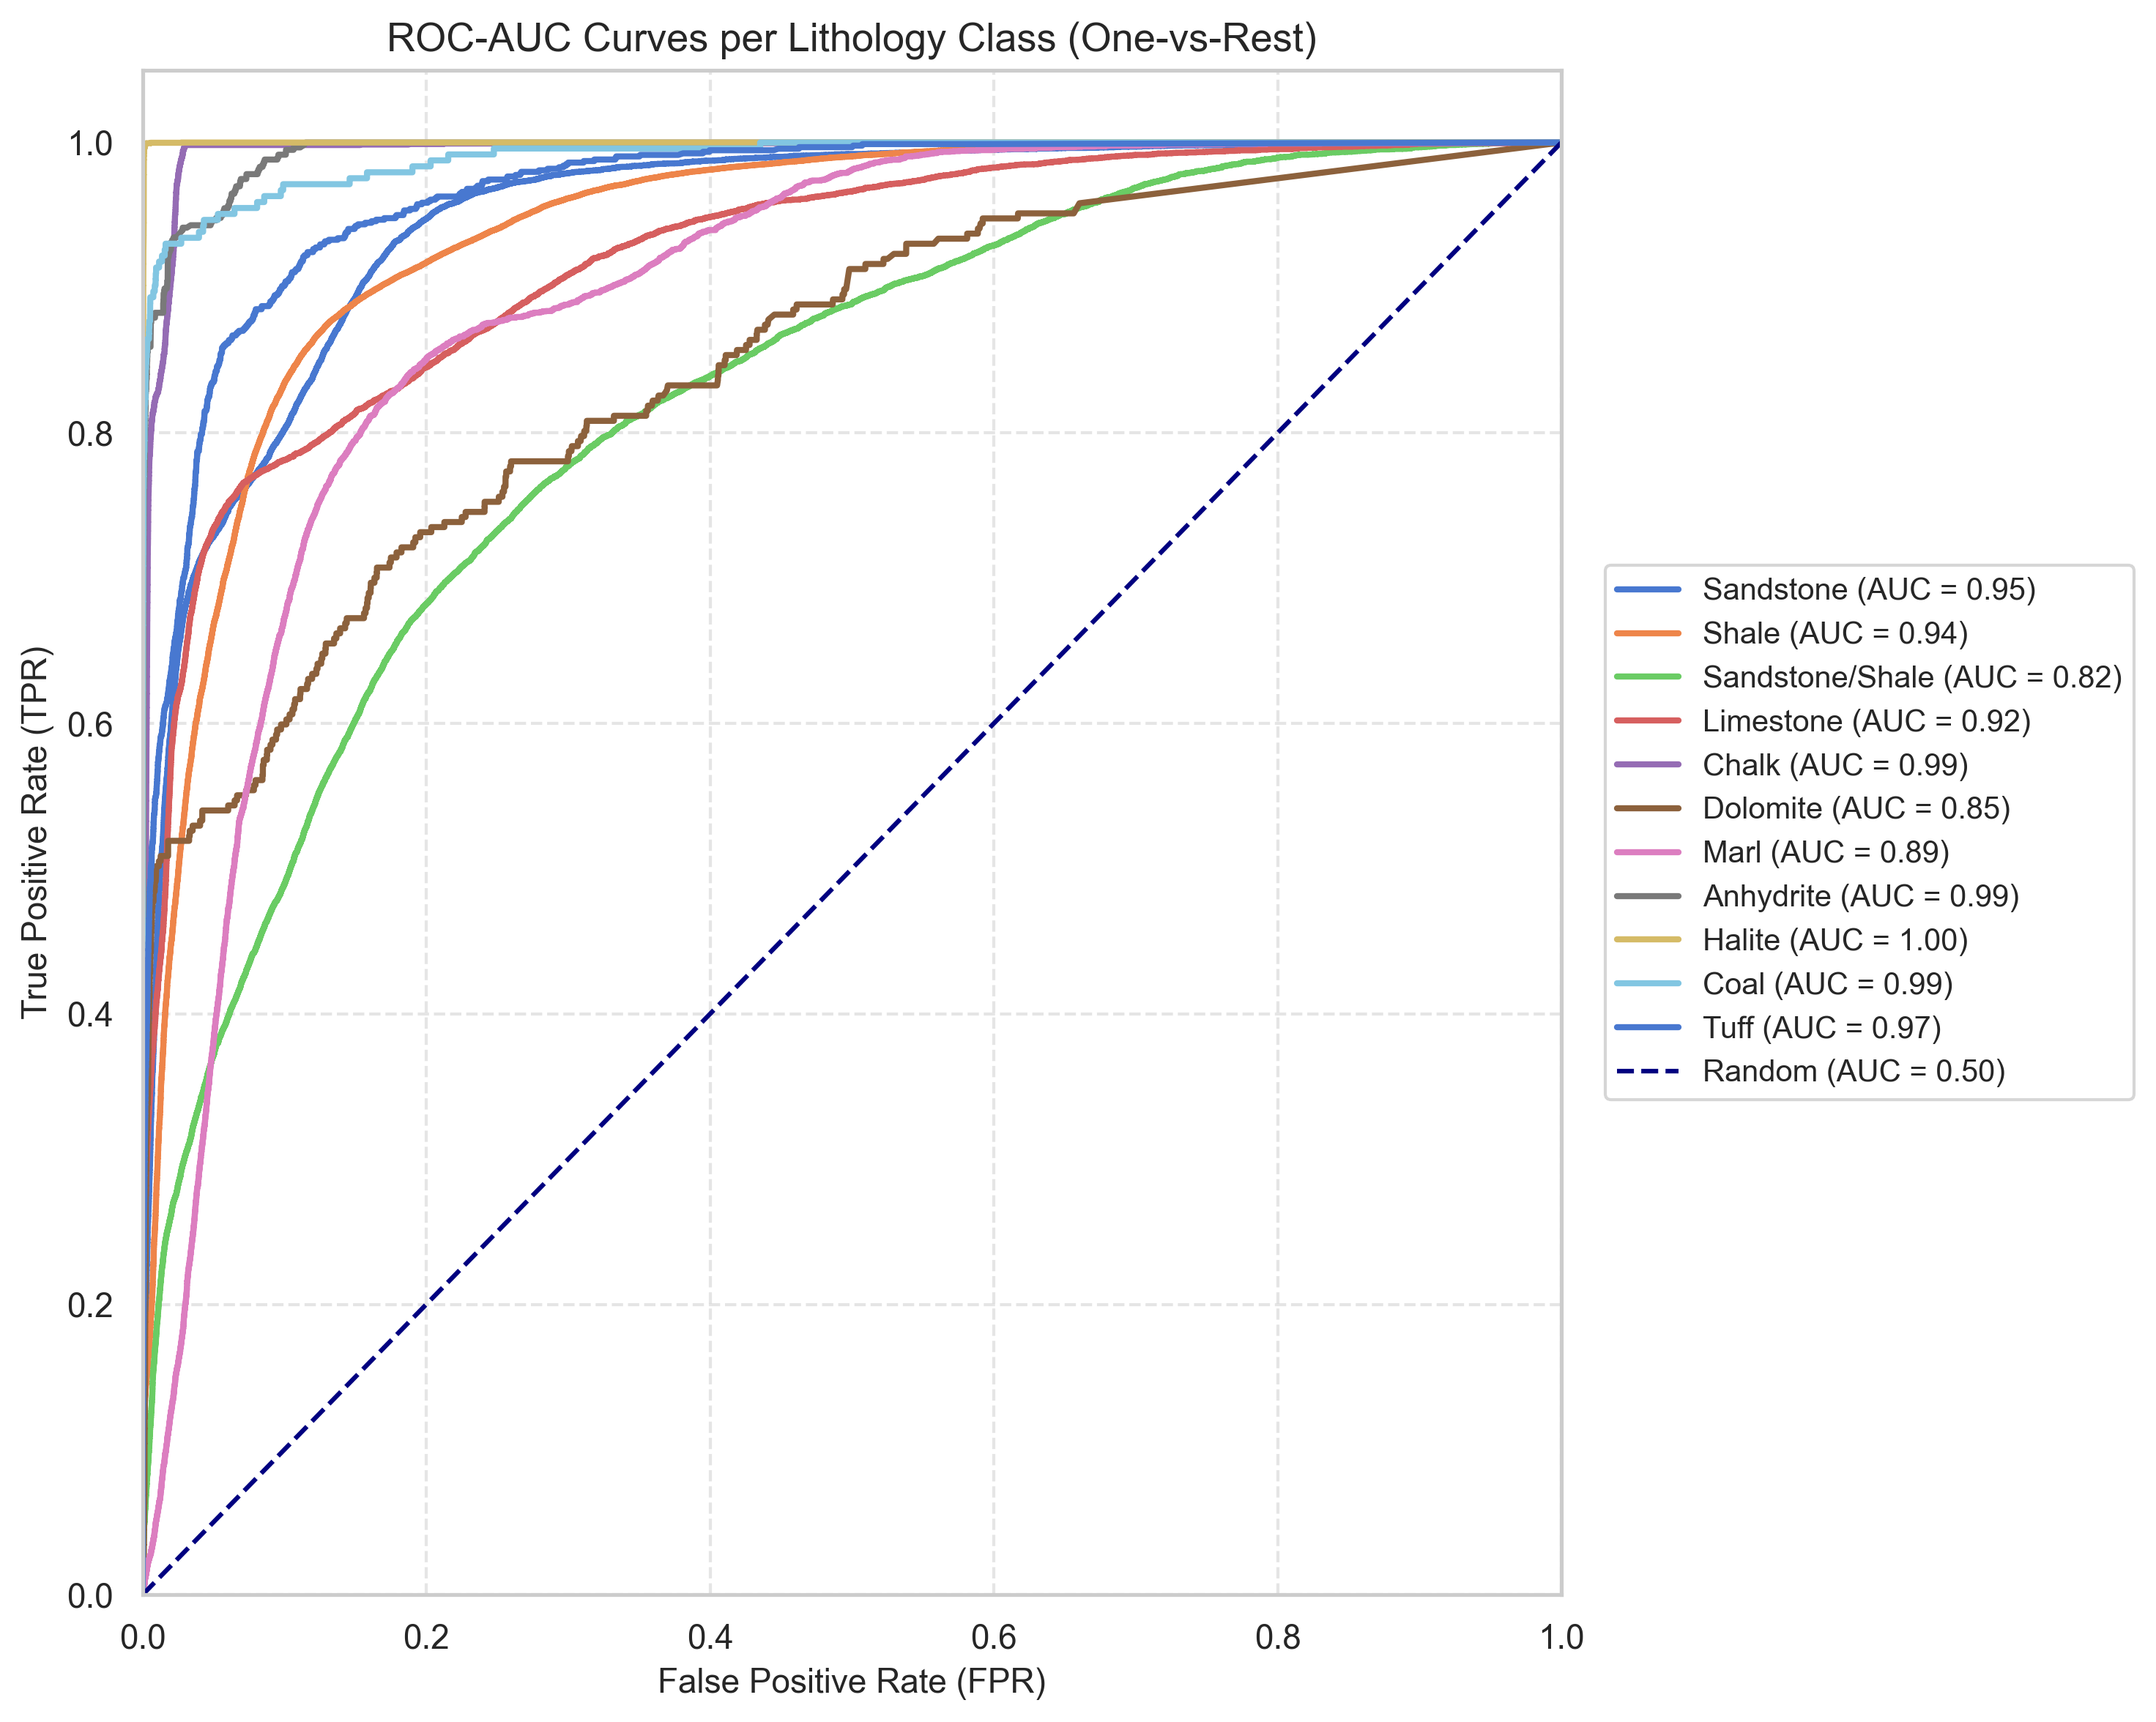

In [4]:
from src.models.rf_cb_optuna import RandomForest
from src.metrics import LithologyEvaluator

loaded_trainer = RandomForest.load('models/random_forest_optuna.joblib')
preds_test = loaded_trainer.predict(df_test)
print(classification_report(y_test, preds_test))

probs_test = loaded_trainer.predict_proba(df_test)
classes = loaded_trainer.pipeline.classes_

evaluator = LithologyEvaluator()
evaluator.plot_all(
    y_true=y_test,
    y_pred=preds_test,
    val_probs=probs_test,
    classes=classes,
    output_dir="reports/figures/rf_cb_optuna",
)

Модель загружена из: models/baseline_sgd.joblib


/Users/polina/miniforge3/envs/ml_course/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/polina/miniforge3/envs/ml_course/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/polina/miniforge3/envs/ml_course/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

               precision    recall  f1-score   support

 Argillaceous       0.87      0.91      0.89     77164
     Basement       0.00      0.00      0.00         0
   Carbonates       0.69      0.72      0.70     11566
         Coal       0.39      0.84      0.53       244
   Evaporites       0.97      0.96      0.96      7095
Siliciclastic       0.77      0.66      0.71     26328

     accuracy                           0.84    122397
    macro avg       0.62      0.68      0.63    122397
 weighted avg       0.84      0.84      0.84    122397

Матрица ошибок сохранена в: /Users/polina/VSCode/ML/Lithology_project/Lithology prediction/reports/figures/grouped_baseline_test/confusion_matrix.png


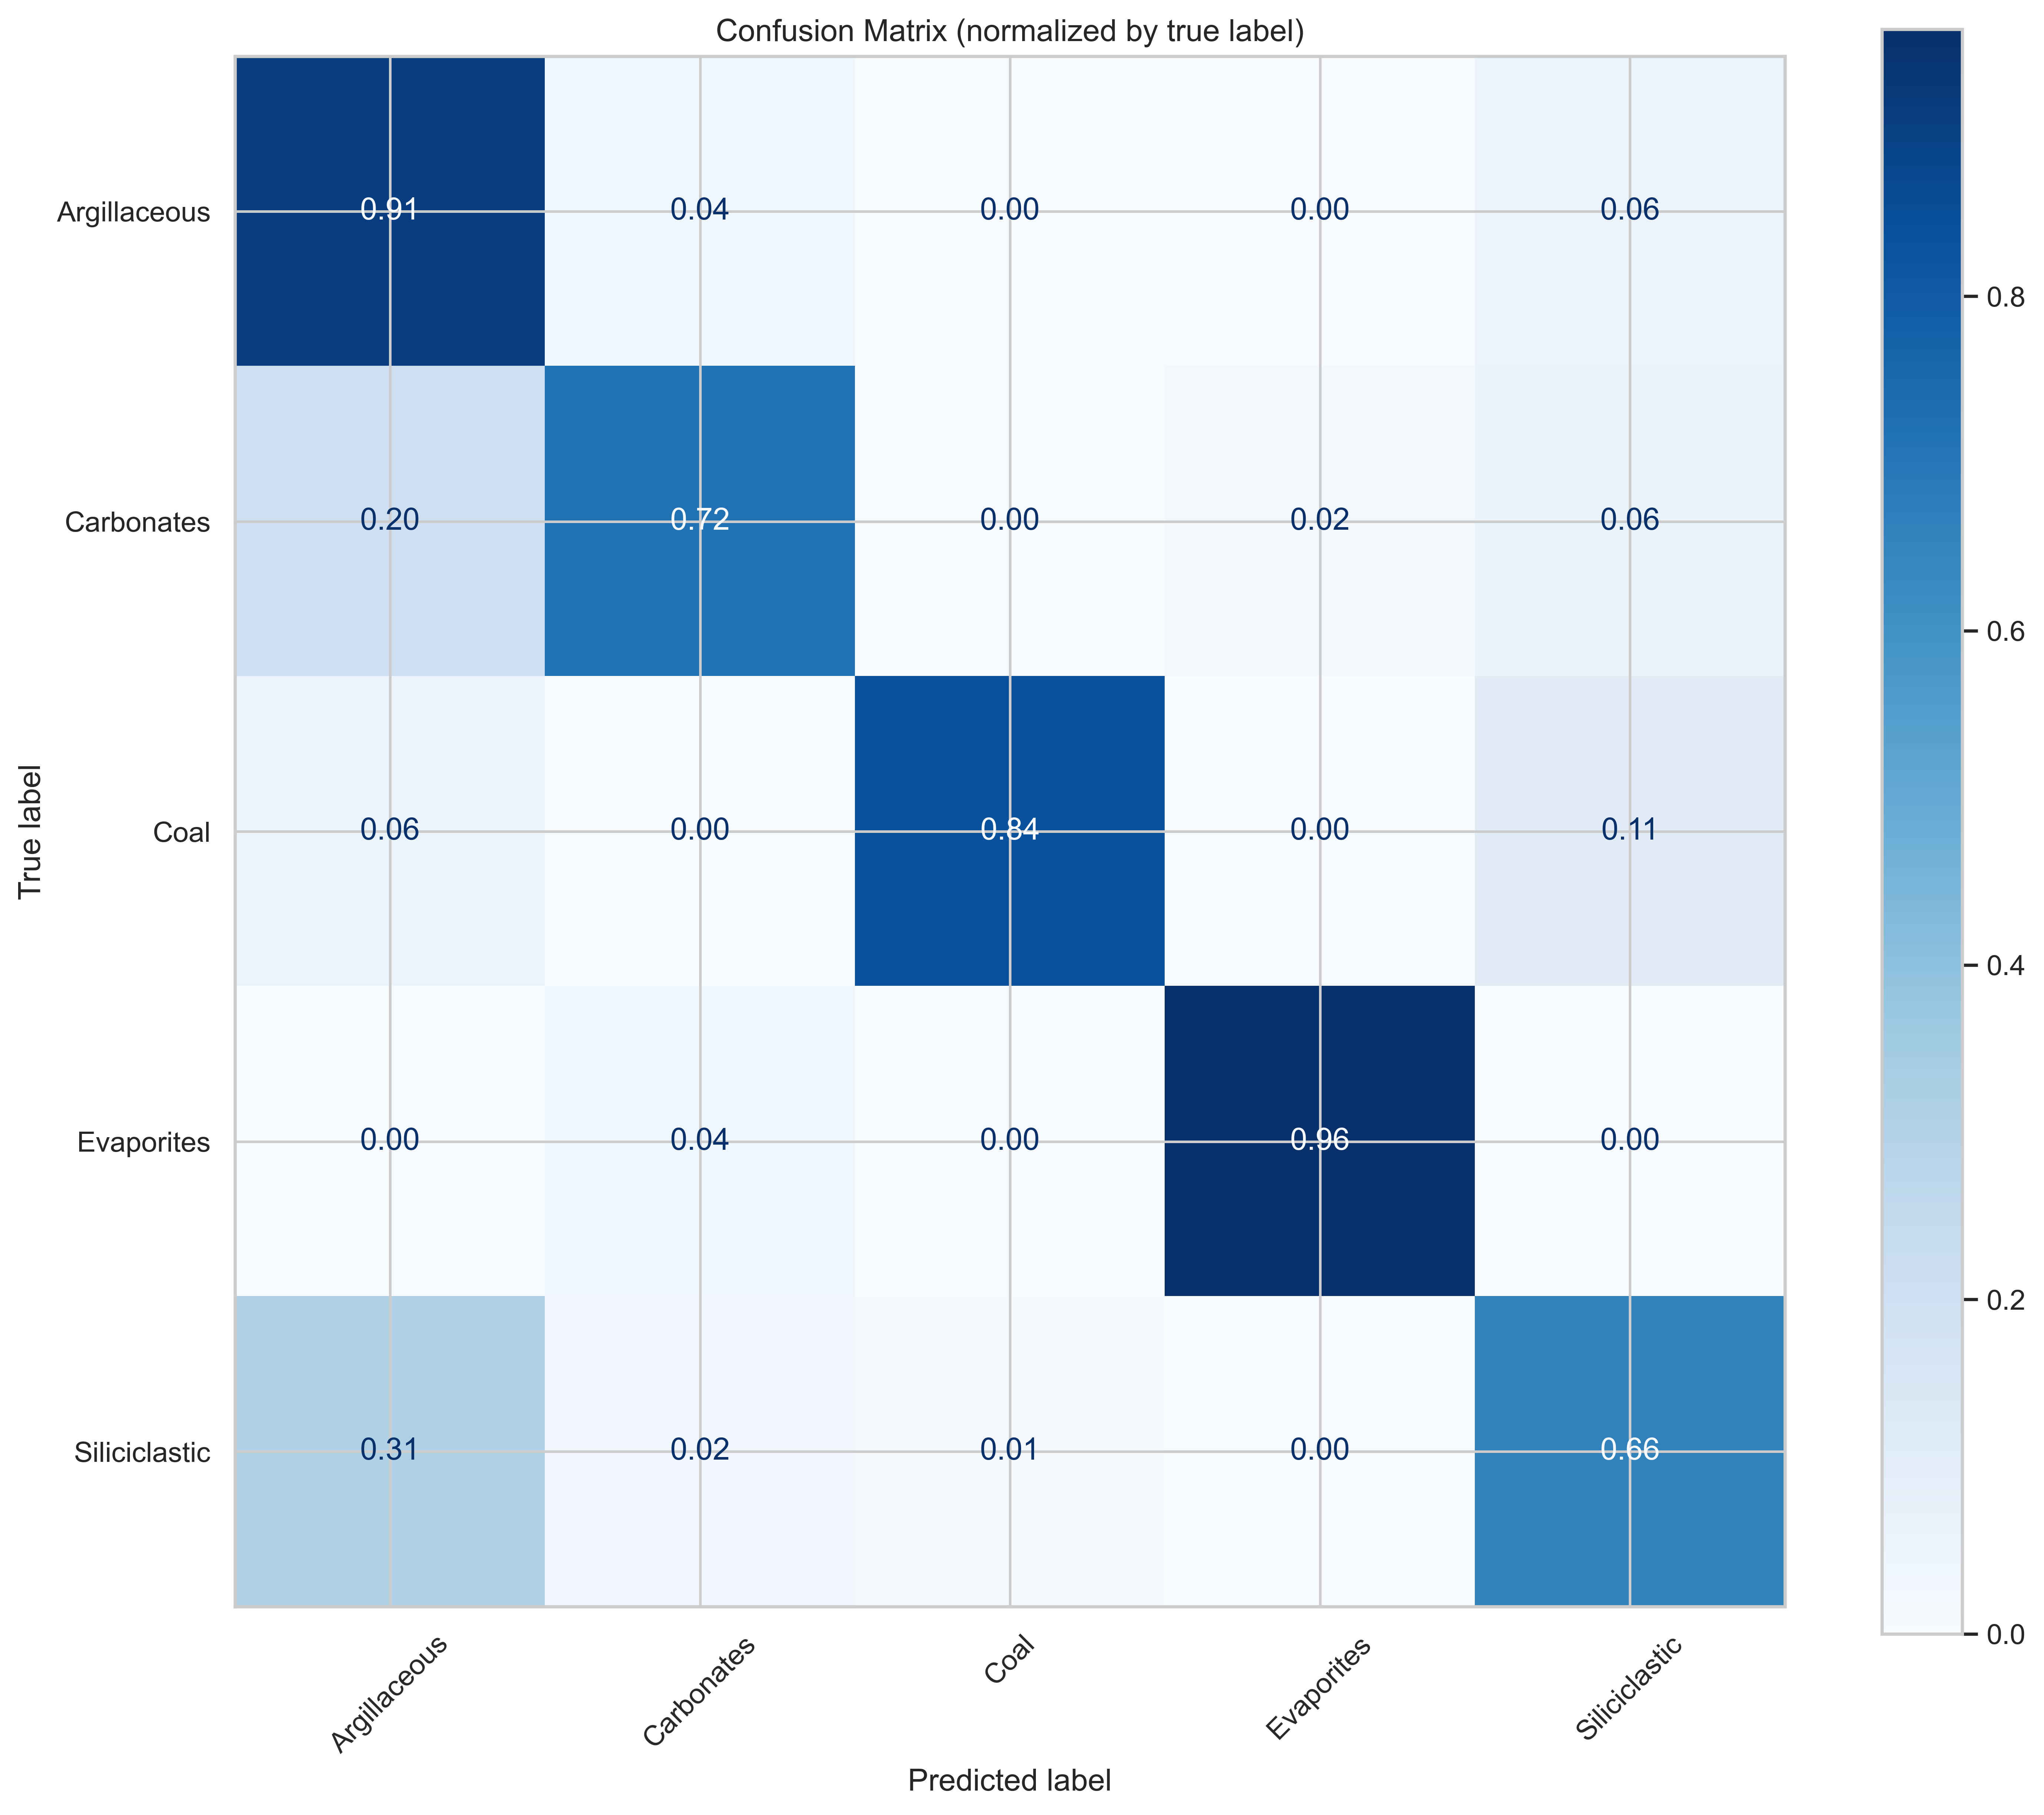

ROC-AUC графики сохранены в: /Users/polina/VSCode/ML/Lithology_project/Lithology prediction/reports/figures/grouped_baseline_test/roc_auc_curves.png


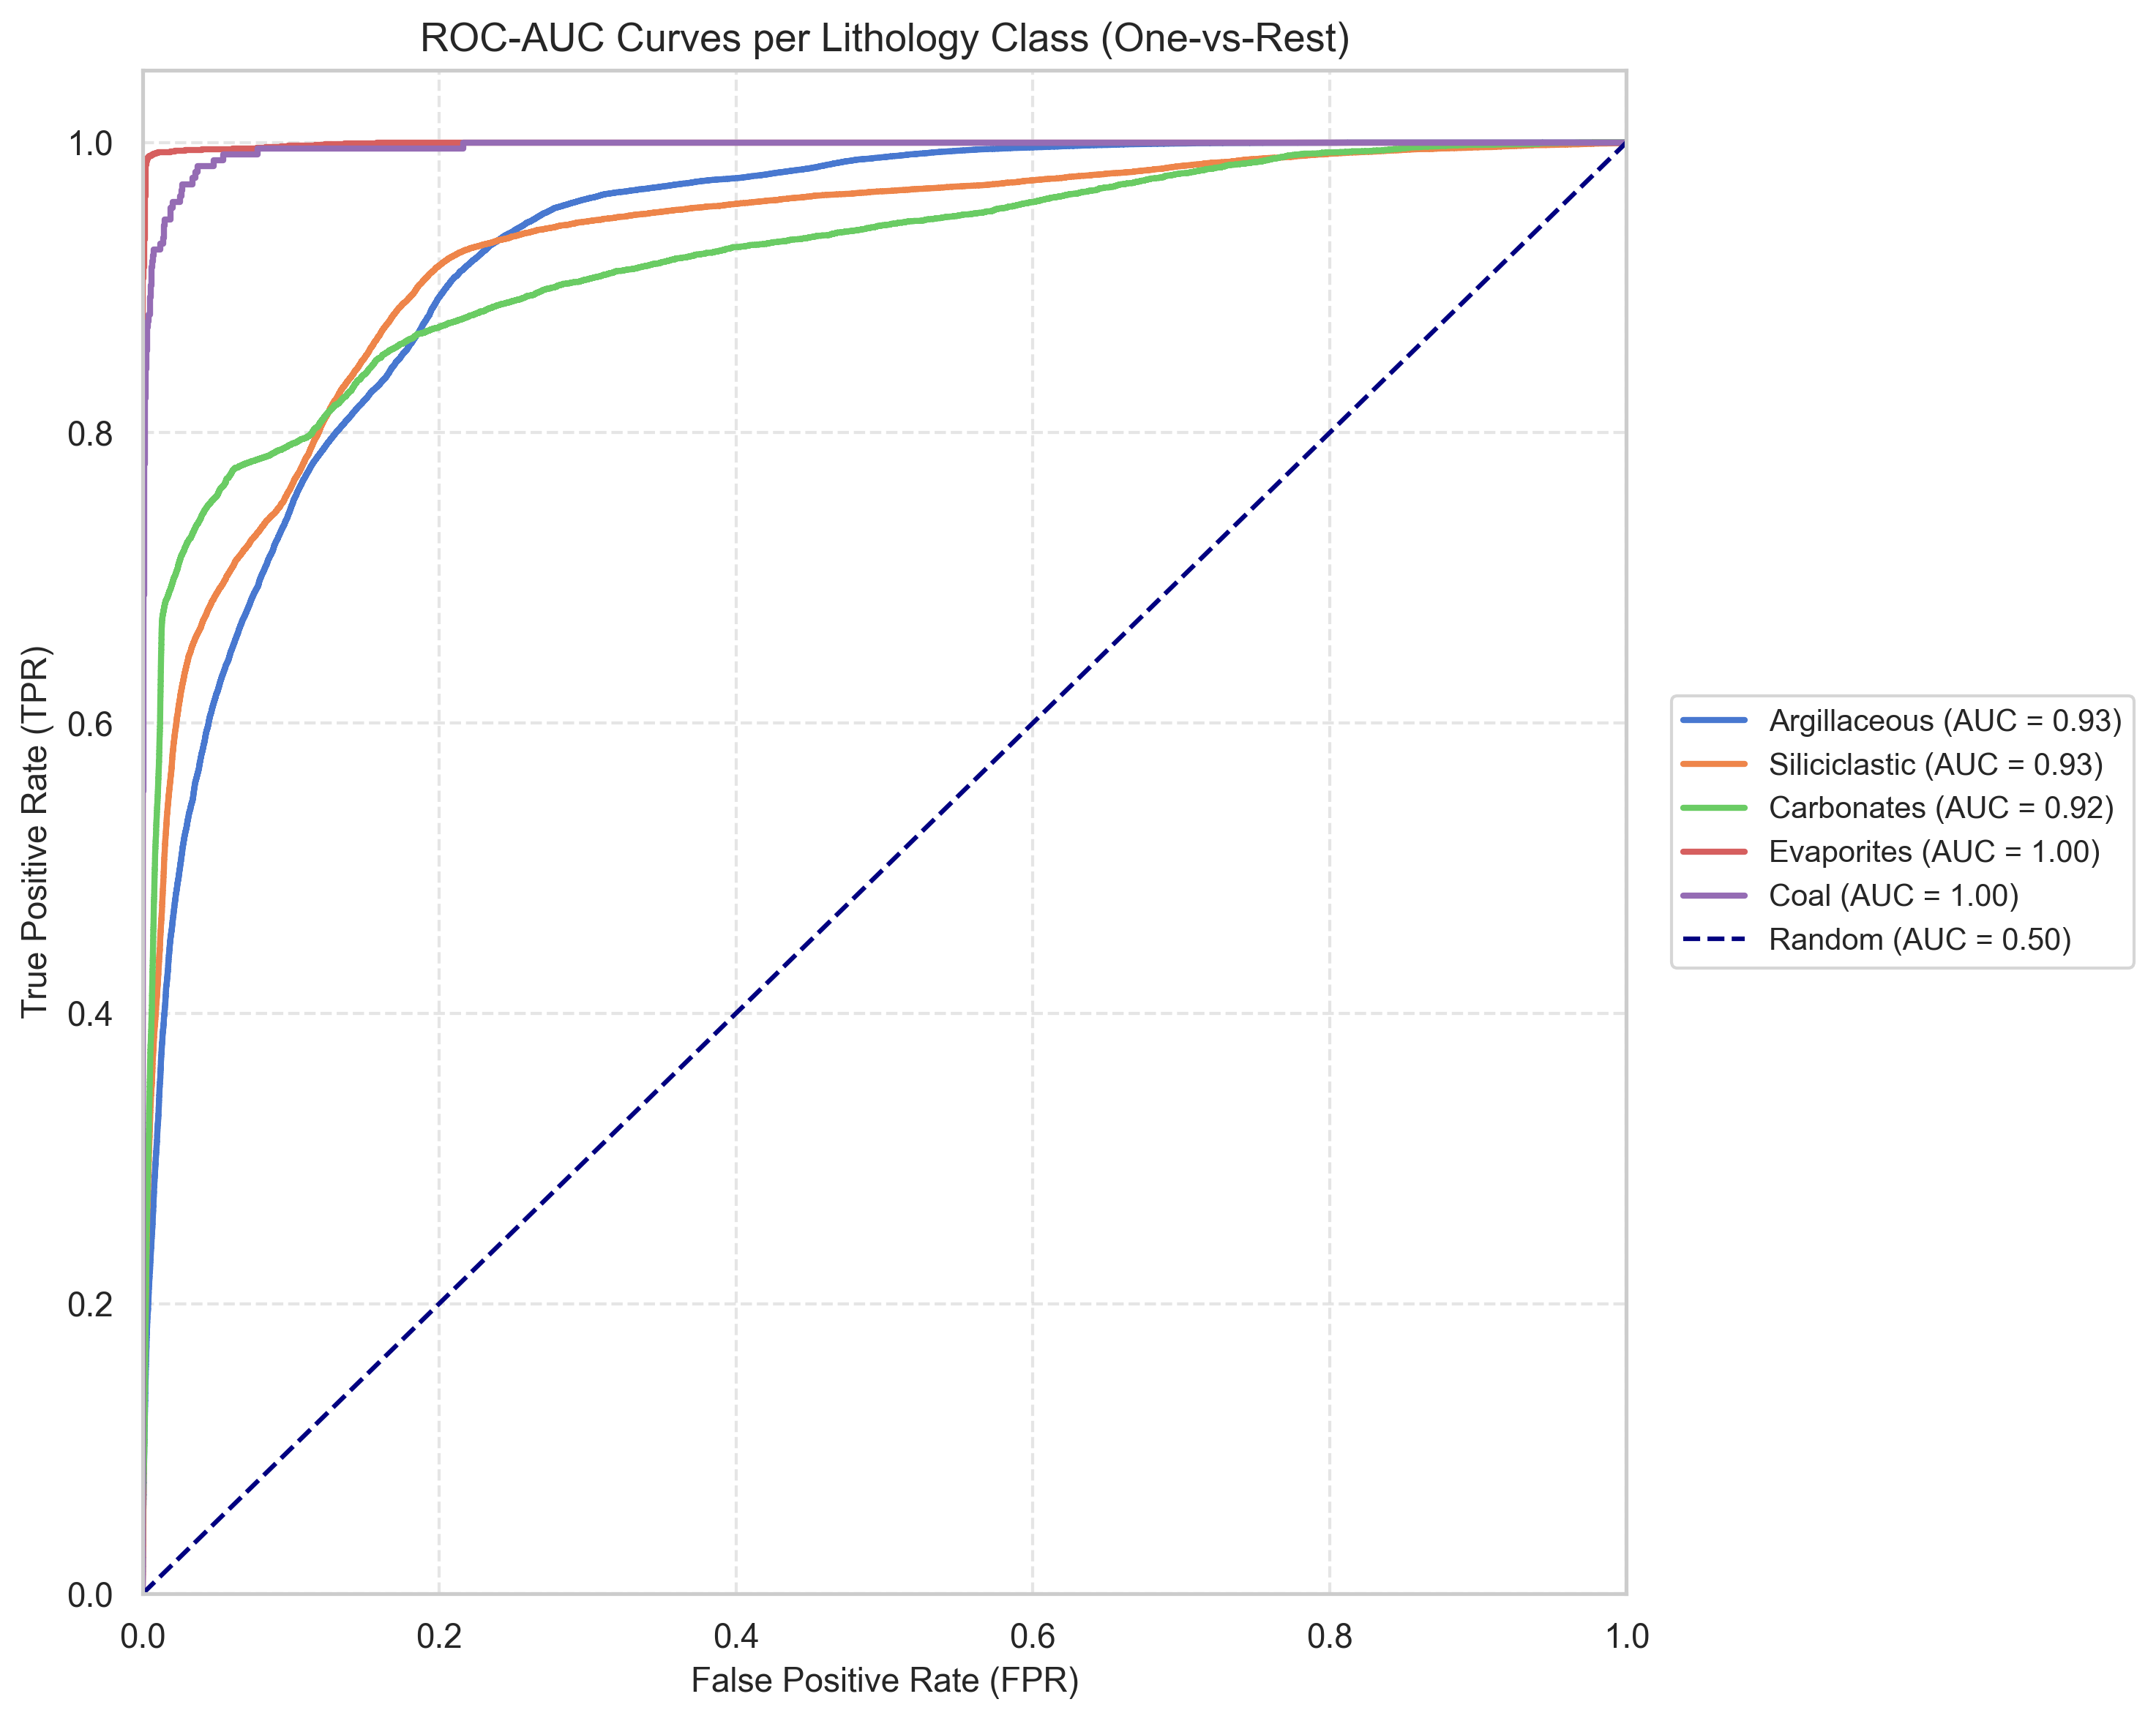

✨ Готово! Графики ROC-AUC


In [5]:
from src.class_grouper import LithologyClassGrouper

united_classes = {
    'Argillaceous': [65000, 80000, 99000],   # Shale, Marl, Tuff
    'Siliciclastic': [30000, 65030],         # Sandstone, Sandstone/Shale
    'Carbonates': [70000, 70032, 74000],     # Limestone, Chalk, Dolomite
    'Evaporites': [86000, 88000],            # Anhydrite, Halite
    'Coal': 90000,                           # Coal
    'Basement': 93000                        # Basement
}

grouper = LithologyClassGrouper(united_classes)
df_grouped = grouper.transform(df_test, target_col='FORCE_2020_LITHOFACIES_LITHOLOGY')
y_test_grouped = df_grouped['FORCE_2020_LITHOFACIES_LITHOLOGY']


MODEL_PATH = Path("models/baseline_sgd.joblib")
loaded_trainer = Baseline.load(str(MODEL_PATH))

raw_preds = loaded_trainer.predict(df_grouped)
preds_grouped = grouper.transform_series(pd.Series(raw_preds)).values
raw_probs = loaded_trainer.predict_proba(df_grouped)
model_classes = loaded_trainer.pipeline.classes_


probs_df = pd.DataFrame(raw_probs, columns=model_classes)

grouped_probs_df = pd.DataFrame(index=probs_df.index)


for group_name, old_classes in united_classes.items():
    if not isinstance(old_classes, list):
        old_classes = [old_classes]
    
    matching_cols = [col for col in probs_df.columns if col in old_classes or str(col) in [str(c) for c in old_classes]]
    
    if matching_cols:
        grouped_probs_df[group_name] = probs_df[matching_cols].sum(axis=1)
    else:
        grouped_probs_df[group_name] = 0.0

target_classes = list(united_classes.keys())
probs_test_grouped = grouped_probs_df[target_classes].values

print(classification_report(y_test_grouped, preds_grouped))

evaluator = LithologyEvaluator()
evaluator.plot_all(
    y_true=y_test_grouped,
    y_pred=preds_grouped,
    val_probs=probs_test_grouped,
    classes=target_classes,
    output_dir=str(BASE_DIR / "reports" / "figures" / "grouped_baseline_test"),
)

print("✨ Готово! Графики ROC-AUC")

Модель загружена из: models/random_forest_grouped_optuna.joblib
               precision    recall  f1-score   support

 Argillaceous       0.86      0.95      0.90     77164
   Carbonates       0.86      0.67      0.75     11566
         Coal       0.91      0.39      0.55       244
   Evaporites       0.99      0.77      0.86      7095
Siliciclastic       0.75      0.63      0.69     26328

     accuracy                           0.85    122397
    macro avg       0.87      0.68      0.75    122397
 weighted avg       0.84      0.85      0.84    122397

Матрица ошибок сохранена в: /Users/polina/VSCode/ML/Lithology_project/Lithology prediction/reports/figures/grouped_rf_test/confusion_matrix.png


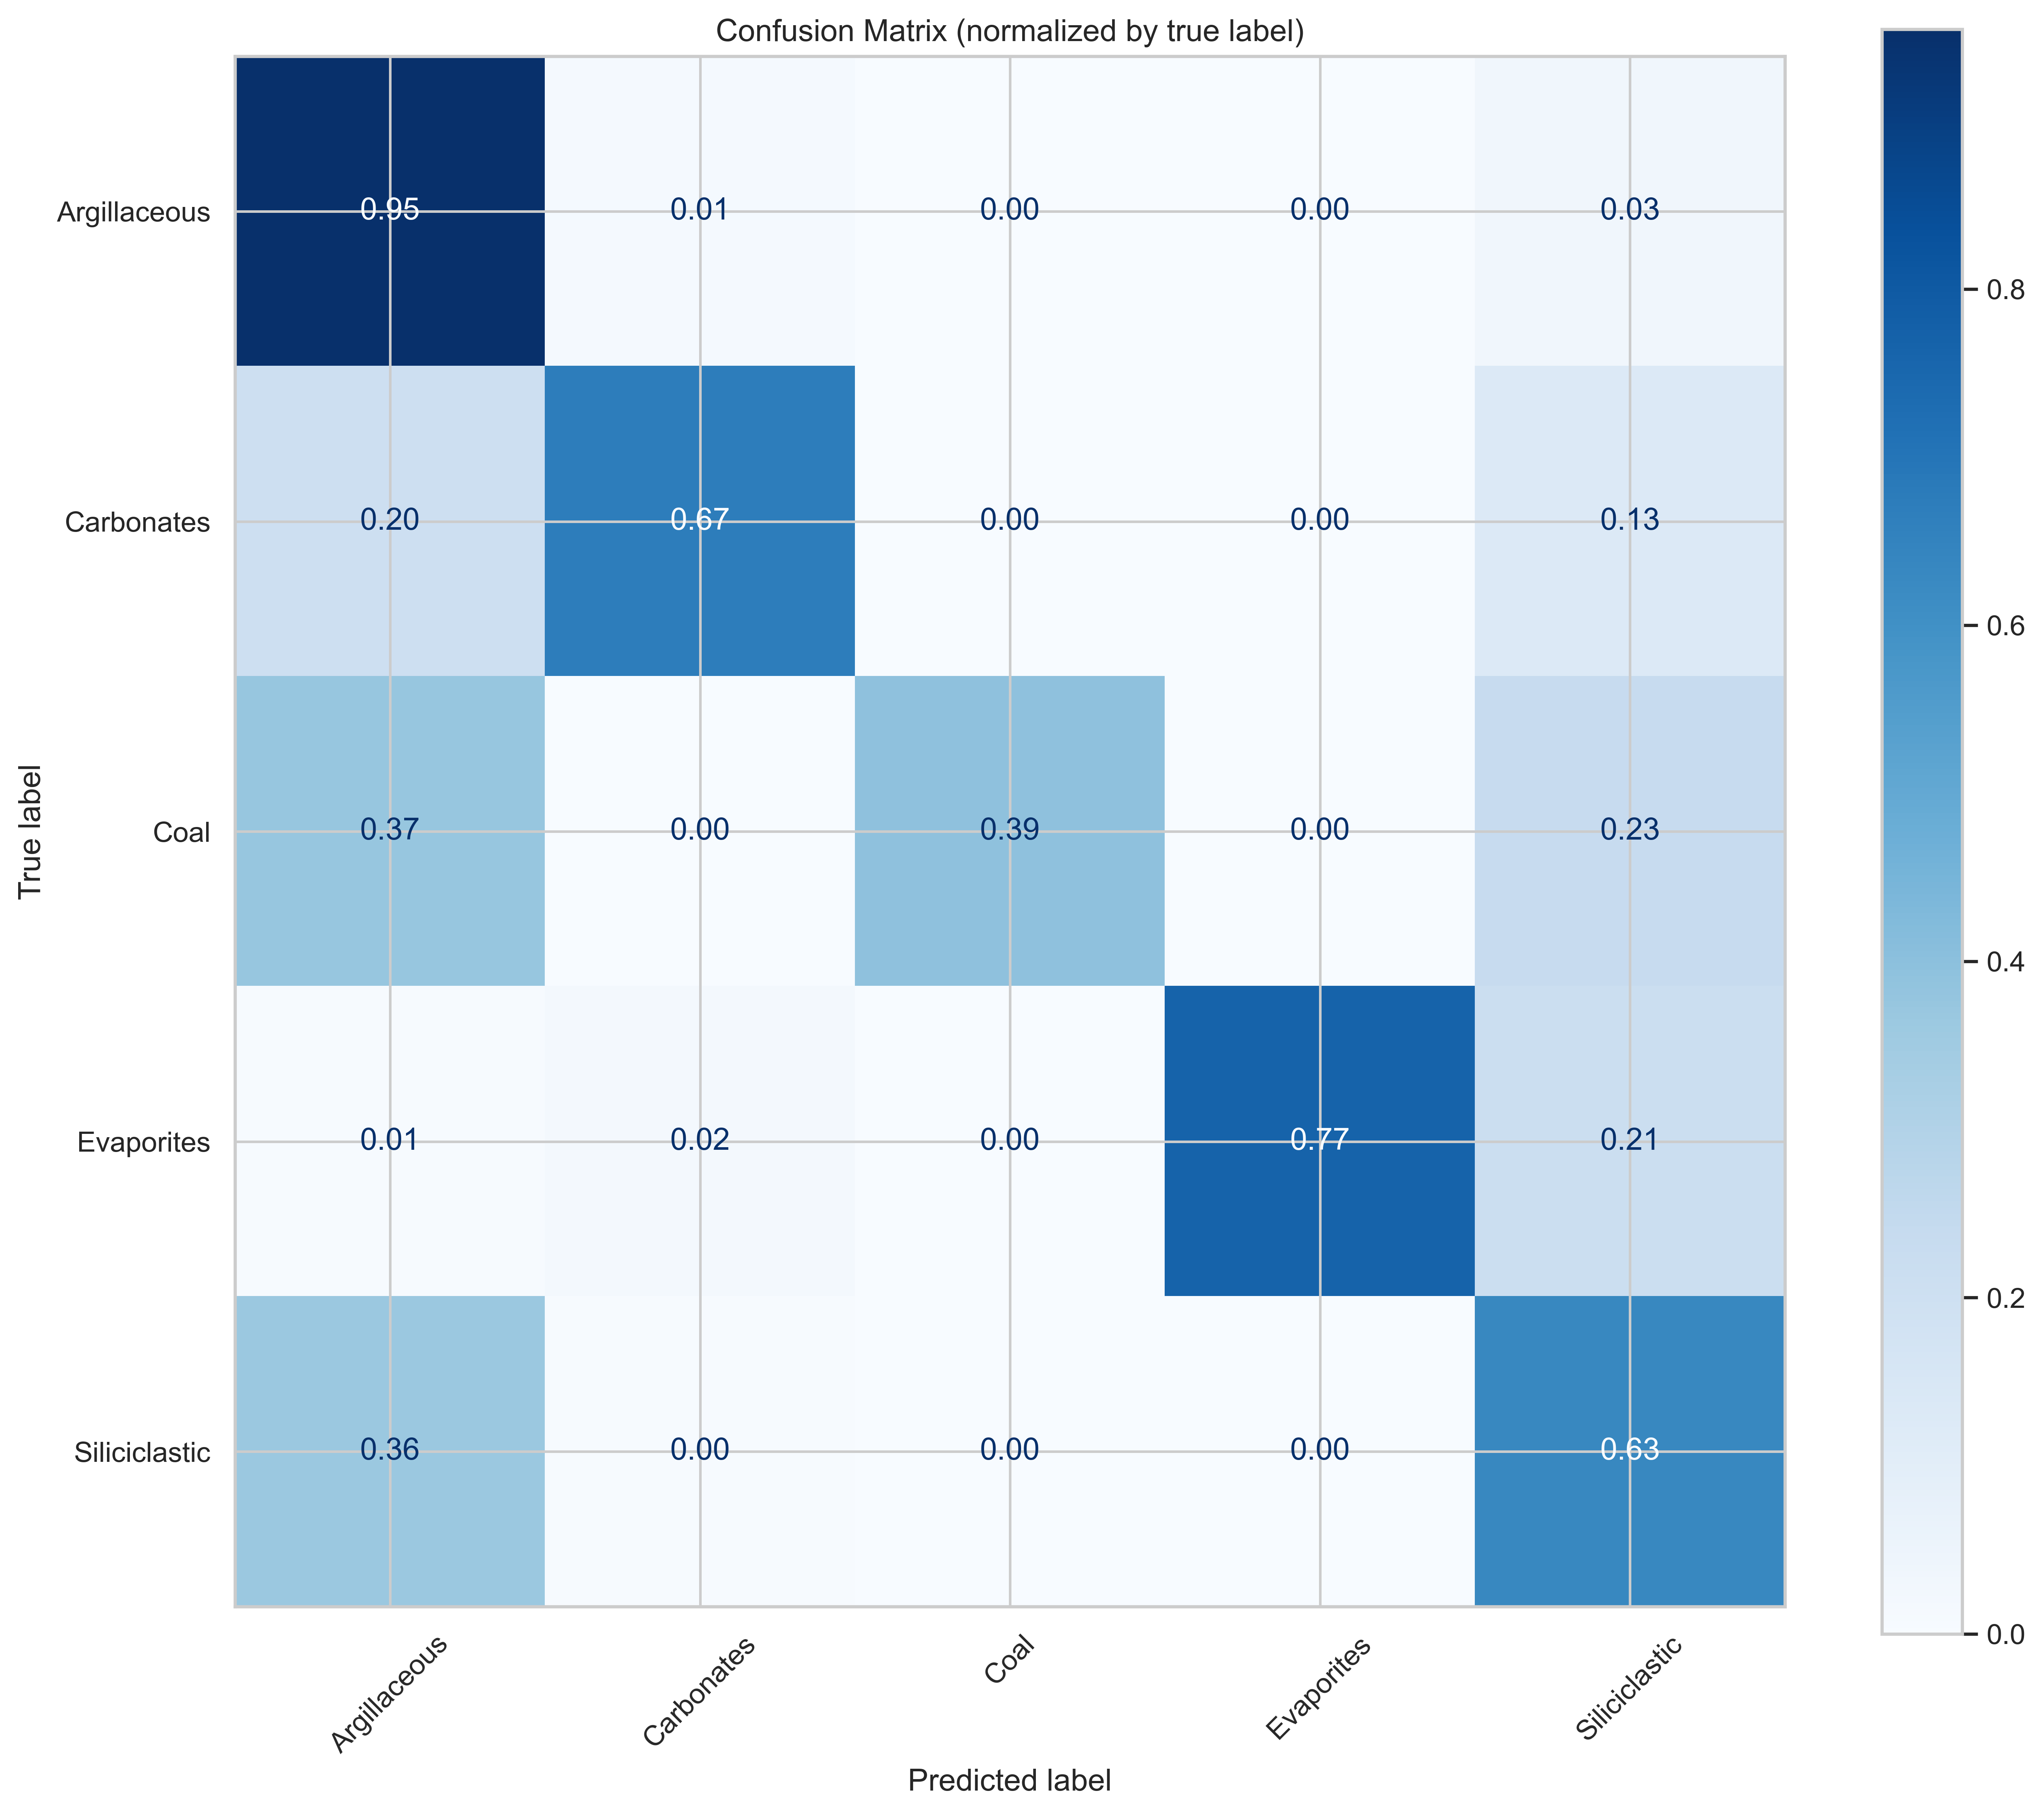

ROC-AUC графики сохранены в: /Users/polina/VSCode/ML/Lithology_project/Lithology prediction/reports/figures/grouped_rf_test/roc_auc_curves.png


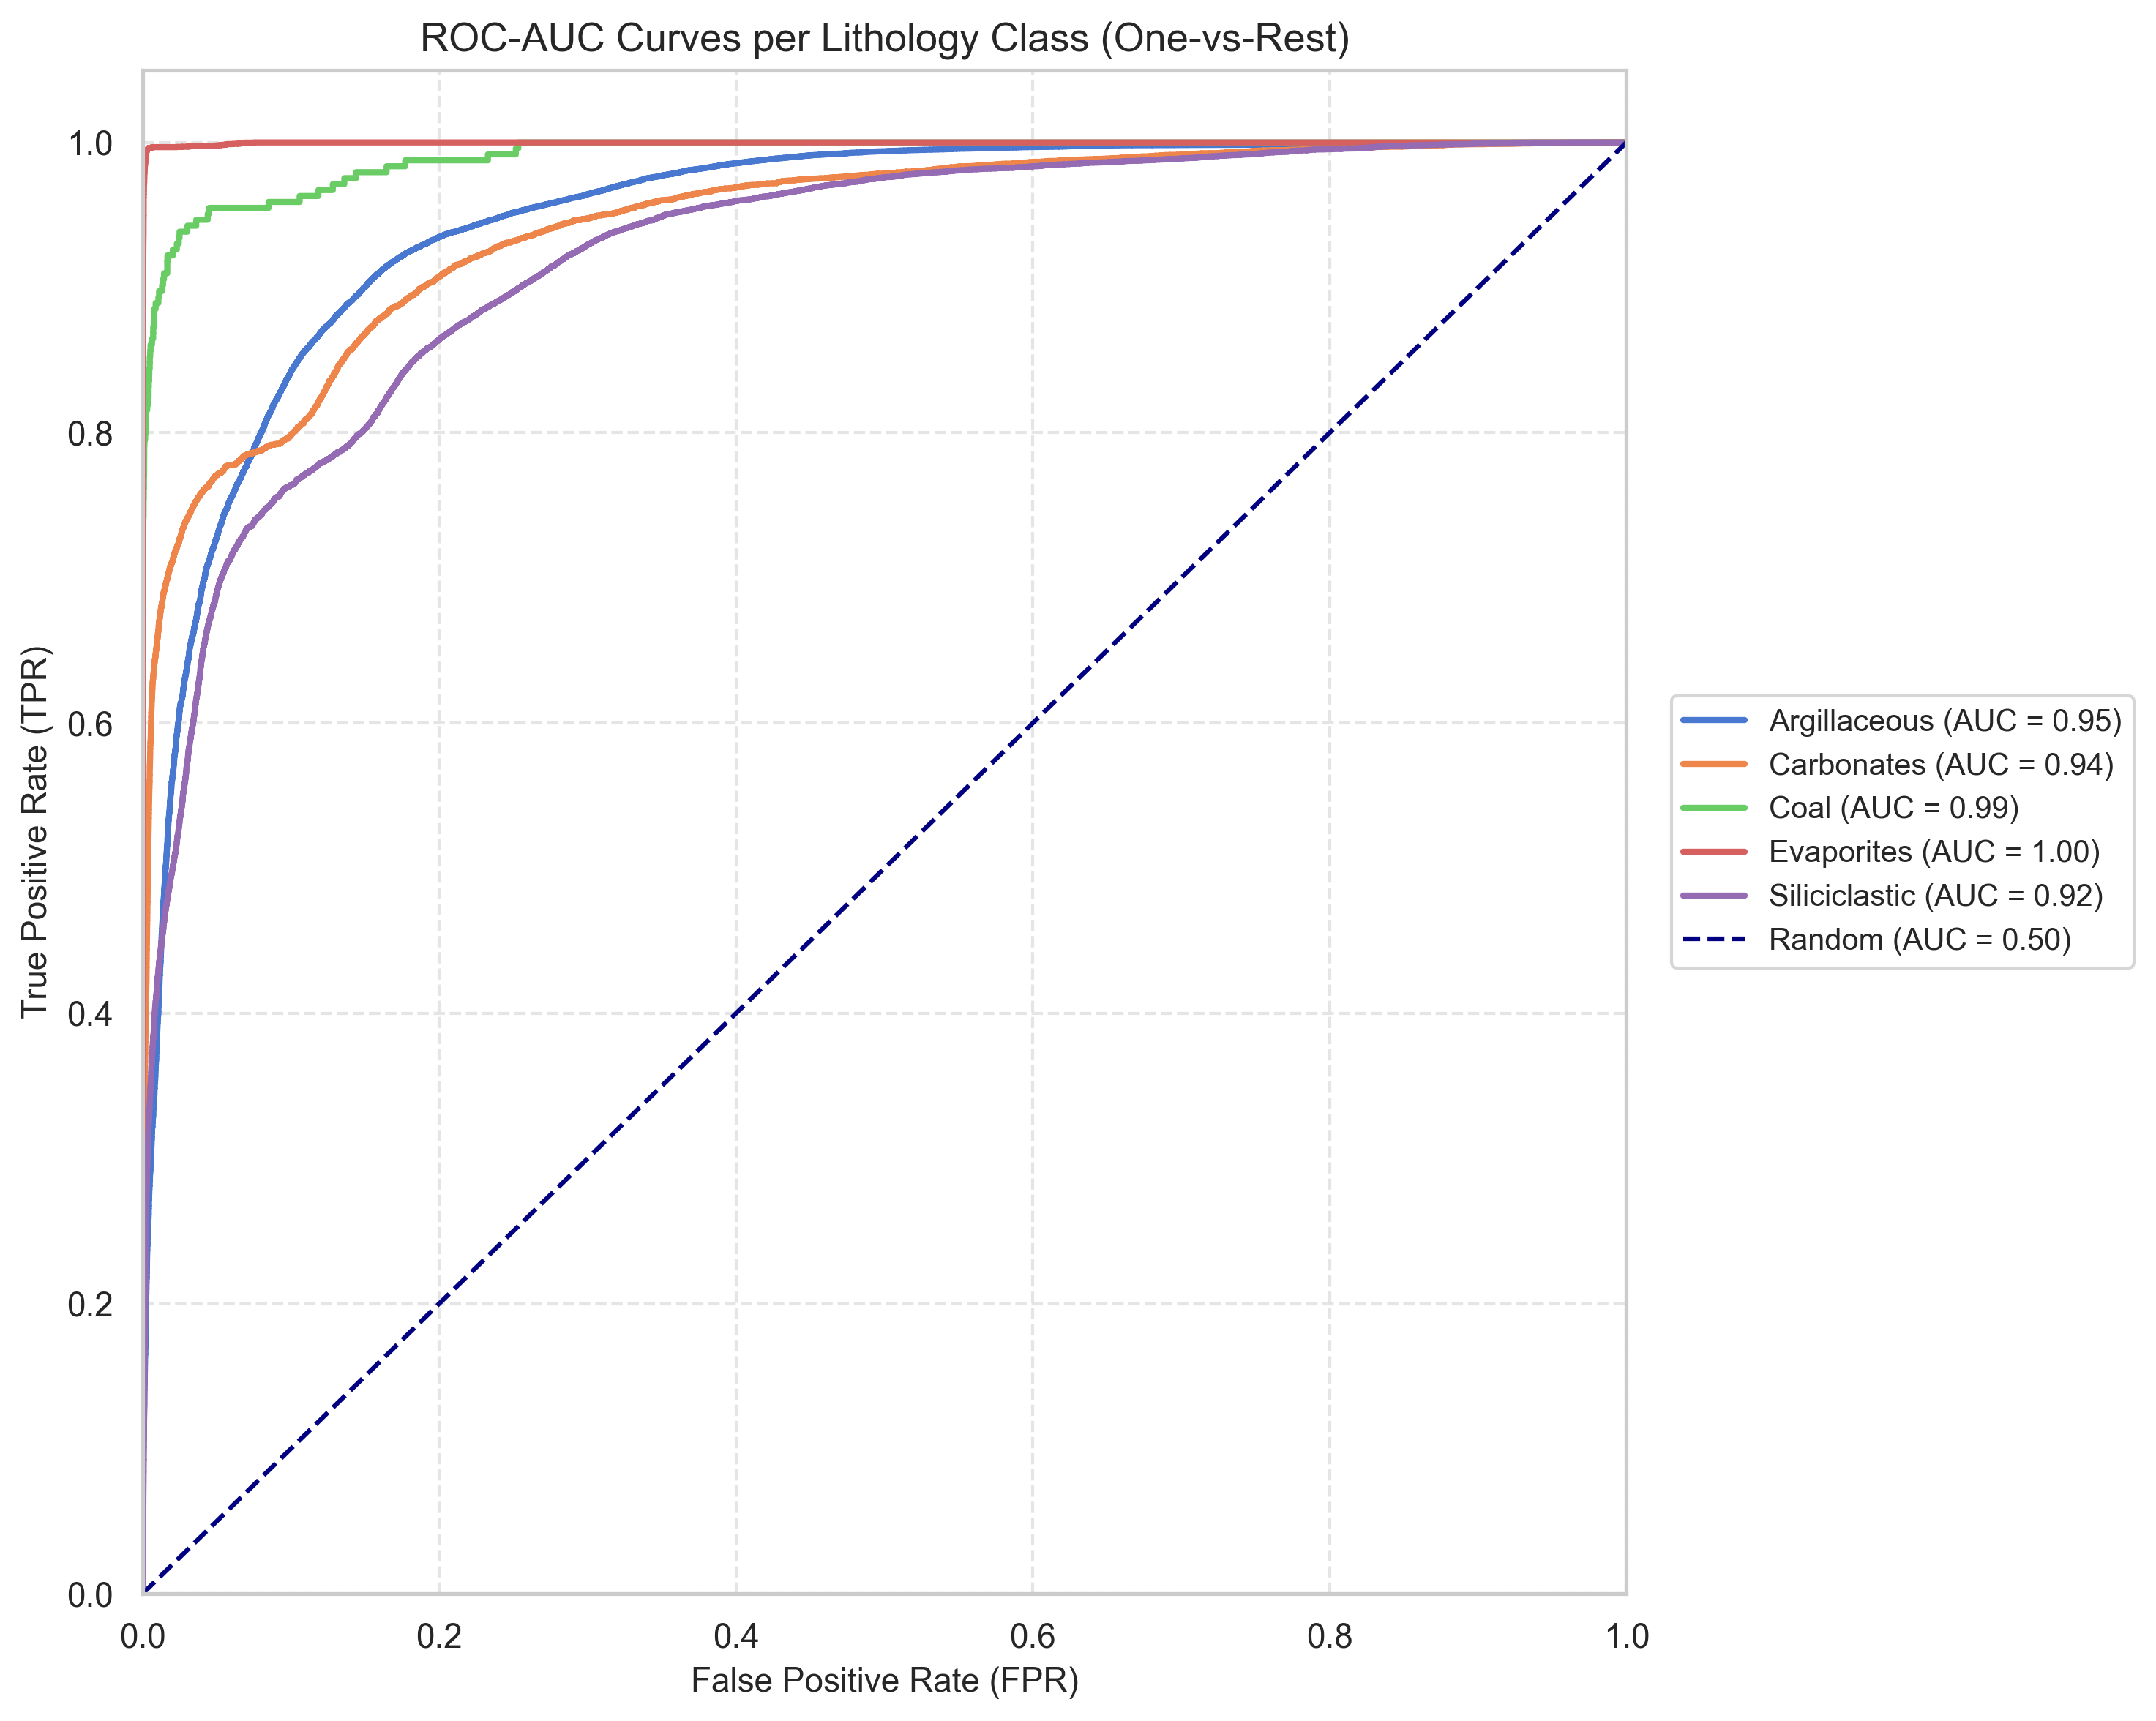

✨ Оценка на тесте завершена! Графики и метрики сохранены.


In [6]:
from pathlib import Path
import pandas as pd
from src.class_grouper import LithologyClassGrouper
from src.models.rf_cb_optuna import RandomForest
from src.metrics import LithologyEvaluator


united_classes = {
    'Argillaceous': [65000, 80000, 99000],   # Shale, Marl, Tuff
    'Siliciclastic': [30000, 65030],         # Sandstone, Sandstone/Shale
    'Carbonates': [70000, 70032, 74000],     # Limestone, Chalk, Dolomite
    'Evaporites': [86000, 88000],            # Anhydrite, Halite
    'Coal': 90000,                           # Coal
    'Basement': 93000                        # Basement
}

grouper = LithologyClassGrouper(united_classes)
df_test_grouped = grouper.transform(df_test, target_col='FORCE_2020_LITHOFACIES_LITHOLOGY')
y_test_grouped = df_test_grouped['FORCE_2020_LITHOFACIES_LITHOLOGY']

MODEL_PATH = Path("models/random_forest_grouped_optuna.joblib")
loaded_trainer = RandomForest.load(str(MODEL_PATH))

preds_test = loaded_trainer.predict(df_test_grouped)
probs_test = loaded_trainer.predict_proba(df_test_grouped)
classes = loaded_trainer.pipeline.classes_

print(classification_report(y_test_grouped, preds_test))

evaluator = LithologyEvaluator()
evaluator.plot_all(
    y_true=y_test_grouped,
    y_pred=preds_test,
    val_probs=probs_test,
    classes=classes,
    output_dir=str(BASE_DIR / "reports" / "figures" / "grouped_rf_test"),
)

print("✨ Оценка на тесте завершена! Графики и метрики сохранены.")